In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from src.load_data import *
from src.linear_pipeline import *
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression
from src.metrics import *
import optuna
import joblib

In [2]:
df = get_dataset()
X_train, X_test, y_train, y_test = split_data(df)
preprocessor = get_preprocessor()

In [3]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [4]:
for k in [10, 50, 100, 200, 500]:
    pipeline_k = Pipeline([
        ("geo_cluster", GeoTransformer(n_clusters=k, random_state=42)),
        ("skew_fix", FunctionTransformer(skew_fix)),
        ("binning", FunctionTransformer(binning)),
        ("preprocessor", get_preprocessor()),
        ("model", LinearRegression())
    ])
    scores = cross_val_score(pipeline_k, X_train, y_train, cv=5, scoring='r2')
    print(f"k={k}: mean={scores.mean():.4f}, std={scores.std():.4f}")

k=10: mean=0.6549, std=0.0087
k=50: mean=0.7023, std=0.0050
k=100: mean=0.7251, std=0.0074
k=200: mean=0.7459, std=0.0071
k=500: mean=0.7769, std=0.0058


In [5]:
for k in [500, 520, 550, 600, 700]:
    pipeline_k = Pipeline([
        ("geo_cluster", GeoTransformer(n_clusters=k, random_state=42)),
        ("skew_fix", FunctionTransformer(skew_fix)),
        ("binning", FunctionTransformer(binning)),
        ("preprocessor", get_preprocessor()),
        ("model", LinearRegression())
    ])
    results = cross_validate(
        pipeline_k, X_train, y_train, cv=5,
        scoring={'r2': 'r2', 'neg_rmse': 'neg_root_mean_squared_error'}
    )
    print(f"k={k}: R²={results['test_r2'].mean():.4f} (std={results['test_r2'].std():.4f}), "
          f"RMSE={-results['test_neg_rmse'].mean():.1f} (std={results['test_neg_rmse'].std():.1f})")

k=500: R²=0.7769 (std=0.0058), RMSE=54595.5 (std=857.2)
k=520: R²=0.7755 (std=0.0059), RMSE=54772.4 (std=971.3)
k=550: R²=0.7763 (std=0.0086), RMSE=54669.7 (std=1214.0)
k=600: R²=0.7804 (std=0.0064), RMSE=54162.2 (std=938.7)
k=700: R²=0.7776 (std=0.0049), RMSE=54507.3 (std=878.0)


In [6]:
pipe = Pipeline([
    ("geo_cluster", GeoTransformer(n_clusters=600)),
    ("skew_fix", FunctionTransformer(skew_fix)),
    ("binning", FunctionTransformer(binning)),
    ("preprocessor", get_preprocessor()),
    ("model", LinearRegression())
])

In [7]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('geo_cluster', ...), ('skew_fix', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_clusters,600
,random_state,42
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function ske...t 0x11da2cf60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True


In [8]:
y_train_pred = pipe.predict(X_train)
y_pred = pipe.predict(X_test)

In [9]:
print("TRAINING")
metrics(y_train, y_train_pred)

print("TESTING")
metrics(y_test, y_pred)

TRAINING
Mean absolute Error: 36278.96822279197
Mean squared Error: 2696794981.7455072
Root Mean squared error: 51930.67476689964
R2 Score: 0.7982615995711402
TESTING
Mean absolute Error: 38103.472094143865
Mean squared Error: 2898273597.3479486
Root Mean squared error: 53835.61643882188
R2 Score: 0.7788267903018639


In [10]:
scores = cross_val_score(
    pipe, X_train, y_train,
    cv=5,
    scoring='r2'
)

print("R² per fold:", scores)
print("Mean R²:", scores.mean())
print("Std R²:", scores.std())

R² per fold: [0.79094206 0.77814608 0.77945289 0.78222588 0.77135587]
Mean R²: 0.780424554584911
Std R²: 0.0063598627858559645


In [11]:
joblib.dump(pipe, "models/linear_regression.joblib")

['models/linear_regression.joblib']

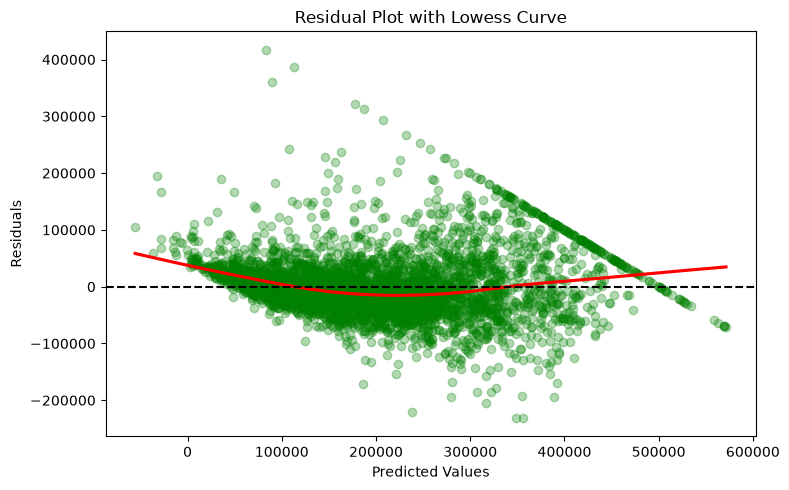

In [12]:
plot_residual_curve(y_test, y_pred, "linear")

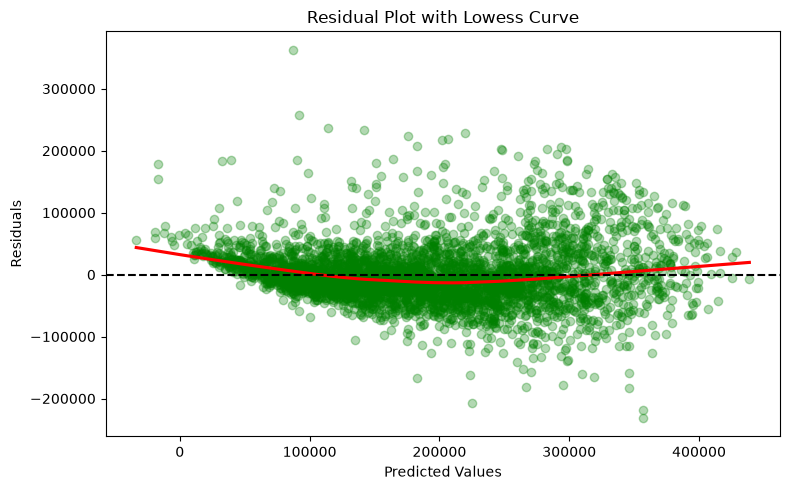

In [13]:
mask_train = y_train != 500001
mask_test = y_test != 500001

X_train_clean, y_train_clean = X_train[mask_train], y_train[mask_train]
X_test_clean, y_test_clean = X_test[mask_test], y_test[mask_test]

pipe.fit(X_train_clean, y_train_clean)
preds_clean = pipe.predict(X_test_clean)

plot_residual_curve(y_test_clean, preds_clean, "linear_no_cap")

>> So linear model is not well fitting into this. heteroscedasticity exists.